0.012493255501361697
Total probability at end: 0.999918785345406


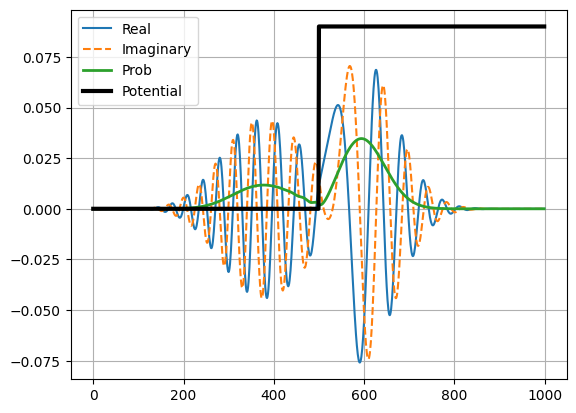

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# step potential
def step(N, v0):
    v = np.zeros(N)
    v[int(N / 2):] = v0
    return v


# constants
m = 1
hbar = 1

# time and space
N = 1000
T = 5000
X, dx = np.linspace(0, N - 1, N, retstep=True)

# potential
V0 = 0.01
V = step(N, V0)
Vmax = V.max()
dt = hbar / (2 * hbar**2 / (m * dx**2) + Vmax)

# constants
c1 = hbar * dt / (m * dx**2)
c2 = 2 * dt / hbar
sigma = 40
x0 = round(N / 2) - 5 * sigma
k0 = np.pi / 20
E = (hbar**2 / 2 / m) * (k0**2 + 0.5 / sigma**2)
print(E)


# Gaussian curve
def gauss(x, x0, sigma):
    return np.exp(-(x - x0)**2 / (2 * sigma**2))


n = int(N / 2)
x = X[:n]
gg = gauss(x, x0, sigma)
cx = np.cos(k0 * x)
sx = np.sin(k0 * x)

R = np.zeros((3, N))
I = np.zeros((3, N))
R[1, :n] = gg * cx
I[1, :n] = gg * sx
R[0, :n] = gg * cx
I[0, :n] = gg * sx

# Normalization
P = dx * np.sum(R[1]**2 + I[1]**2)
nrm = np.sqrt(P)
R = R / nrm
I = I / nrm

for t in range(T + 1):
    R0 = R[1]
    I0 = I[1]
    I[2, 1:-1] = I[0, 1:-1] + c1 * (R0[2:] - 2 * R0[1:-1] + R0[:-2]) - c2 * V[1:-1] * R0[1:-1]
    R[2, 1:-1] = R[0, 1:-1] - c1 * (I0[2:] - 2 * I0[1:-1] + I0[:-2]) + c2 * V[1:-1] * I0[1:-1]
    R[0] = R0
    I[0] = I0
    R[1] = R[2]
    I[1] = I[2]   # <-- this line was missing; without it I[1] never advances,
                  # R and I fall out of sync, and the probability blows up.

# sanity check: total probability should stay close to 1
print("Total probability at end:", dx * np.sum(R[1]**2 + I[1]**2))

plt.grid()
plt.plot(X, R[1], '-', label='Real')
plt.plot(X, I[1], '--', label='Imaginary')
prob = R[1]**2 + I[1]**2
plt.plot(X, 6 * prob, lw=2, label='Prob')
plt.plot(X, 9 * V, 'k', lw=3, label='Potential')
plt.legend()
plt.show()